# Proyecto de Preproceso del Dataset

## Integrantes

- Adria Viñas
- Carmen Candial
- Juan Ceruso
- Maximiliano Cifuentes

## Caso de Estudio

Se cuenta con un dataset con datos de vehículos, principalmente de marca *BMW*.
El objetivo de este dataset es predecir el precio del vehículo, para ello en este proyecto se necesitará realizar todo el data cleaning y data preprocessing de los datos.


## Importación de Librerías y Datos

In [74]:
# Importamos las Librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
# Configuracion de estilo para los gráficos
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_colwidth", 80)

def pretty_table(df):
    return (
        df.style
        .format(precision=2, thousands=",")
        .set_properties(**{
            "text-align": "center",
            "padding": "8px",
            "border": "1px solid #dbeafe"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", "#0b1f3a"),  # azul marino
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("padding", "10px"),
                    ("border", "1px solid #dbeafe")
                ]
            },
            {
                "selector": "tbody tr:nth-child(even)",
                "props": [
                    ("background-color", "#e0f2fe")  # celeste
                ]
            },
            {
                "selector": "tbody tr:nth-child(odd)",
                "props": [
                    ("background-color", "white")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("border", "1px solid #dbeafe")
                ]
            },
            {
                "selector": "tbody tr:hover",
                "props": [
                    ("background-color", "#bae6fd")
                ]
            }
        ])
    )

In [76]:
# Importamos el Dataset
df_bmw = pd.read_csv('bmw_pricing.csv')

In [96]:
# Hacemos una copia del Dataset original para trabajar con ella
df_cars = df_bmw.copy()
# Visualizamos las primeras filas del Dataset
pretty_table(df_cars.head())

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
0,nan,118,"140,411.00",100.00,2012-02-01,diesel,black,nan,True,True,False,nan,True,nan,True,nan,"11,300.00",2018-01-01
1,BMW,M4,"13,929.00",317.00,nan,petrol,grey,convertible,True,True,False,nan,False,True,True,True,"69,700.00",2018-02-01
2,BMW,320,"183,297.00",120.00,2012-04-01,diesel,white,nan,False,False,False,nan,True,False,True,False,"10,200.00",2018-02-01
3,BMW,420,"128,035.00",135.00,nan,diesel,red,convertible,True,True,False,nan,True,True,True,nan,"25,100.00",2018-02-01
4,BMW,425,"97,097.00",160.00,nan,diesel,silver,nan,True,True,False,False,False,True,True,True,"33,400.00",2018-04-01


In [97]:
# Analizamos la información general del Dataset
df_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marca                        3873 non-null   object 
 1   modelo                       4840 non-null   object 
 2   km                           4841 non-null   float64
 3   potencia                     4842 non-null   float64
 4   fecha_registro               2420 non-null   object 
 5   tipo_gasolina                4838 non-null   object 
 6   color                        4398 non-null   object 
 7   tipo_coche                   3383 non-null   object 
 8   volante_regulable            4839 non-null   object 
 9   aire_acondicionado           4357 non-null   object 
 10  camara_trasera               4841 non-null   object 
 11  asientos_traseros_plegables  1452 non-null   object 
 12  elevalunas_electrico         4841 non-null   object 
 13  bluetooth         

In [98]:
# Para cada columna, contamos el número de valores únicos y los valores nulos
# junto con el porcentaje que representan.
# En una tabla, ordenada de forma descendente por el porcentaje de valores nulos, mostramos esta información.

df_null_info = []
for column in df_cars.columns:
    unique_values = df_cars[column].nunique()
    null_values = df_cars[column].isnull().sum()
    null_values_perc = round(df_cars[column].isnull().mean() * 100 , 2)
    df_null_info.append({
        "Columna": column,
        "Valores Únicos": unique_values,
        "Valores Nulos": null_values,
        "Porcentaje Nulos": null_values_perc
    })

df_null_info = pd.DataFrame(df_null_info)
df_null_info = df_null_info.sort_values("Porcentaje Nulos", ascending=False)
pretty_table(df_null_info)

,Columna,Valores Únicos,Valores Nulos,Porcentaje Nulos
11,asientos_traseros_plegables,2,"3,391",70.02
4,fecha_registro,180,"2,423",50.03
7,tipo_coche,8,"1,460",30.15
0,marca,1,970,20.03
15,alerta_lim_velocidad,2,728,15.03
13,bluetooth,2,728,15.03
9,aire_acondicionado,2,486,10.04
6,color,10,445,9.19
16,precio,437,6,0.12
5,tipo_gasolina,5,5,0.10


In [99]:
# Contamos el numero de filas duplicadas y las presentamos
duplicated_rows = df_cars.duplicated().sum()
print(f"Número de filas duplicadas: {duplicated_rows}")
if duplicated_rows > 0:
    print("Filas duplicadas:")
    print(df_cars[df_cars.duplicated()])    

Número de filas duplicadas: 0


### Eliminamos los valores de Precio Nulos

In [100]:
type(df_cars)

pandas.core.frame.DataFrame

In [101]:
# Eliminamos las filas nulas de la columna "precio" y analizamos nuevamente la información general del Dataset
df_cars = df_cars.dropna(subset=["precio"])

df_null_info = []
for column in df_cars.columns:
    unique_values = df_cars[column].nunique()
    null_values = df_cars[column].isnull().sum()
    null_values_perc = round(df_cars[column].isnull().mean() * 100 , 2)
    df_null_info.append({
        "Columna": column,
        "Valores Únicos": unique_values,
        "Valores Nulos": null_values,
        "Porcentaje Nulos": null_values_perc
    })

df_null_info = pd.DataFrame(df_null_info)
df_null_info = df_null_info.sort_values("Porcentaje Nulos", ascending=False)
pretty_table(df_null_info)

,Columna,Valores Únicos,Valores Nulos,Porcentaje Nulos
11,asientos_traseros_plegables,2,"3,388",70.04
4,fecha_registro,180,"2,418",49.99
7,tipo_coche,8,"1,458",30.14
0,marca,1,970,20.05
15,alerta_lim_velocidad,2,728,15.05
13,bluetooth,2,728,15.05
9,aire_acondicionado,2,485,10.03
6,color,10,444,9.18
5,tipo_gasolina,5,5,0.10
8,volante_regulable,2,4,0.08


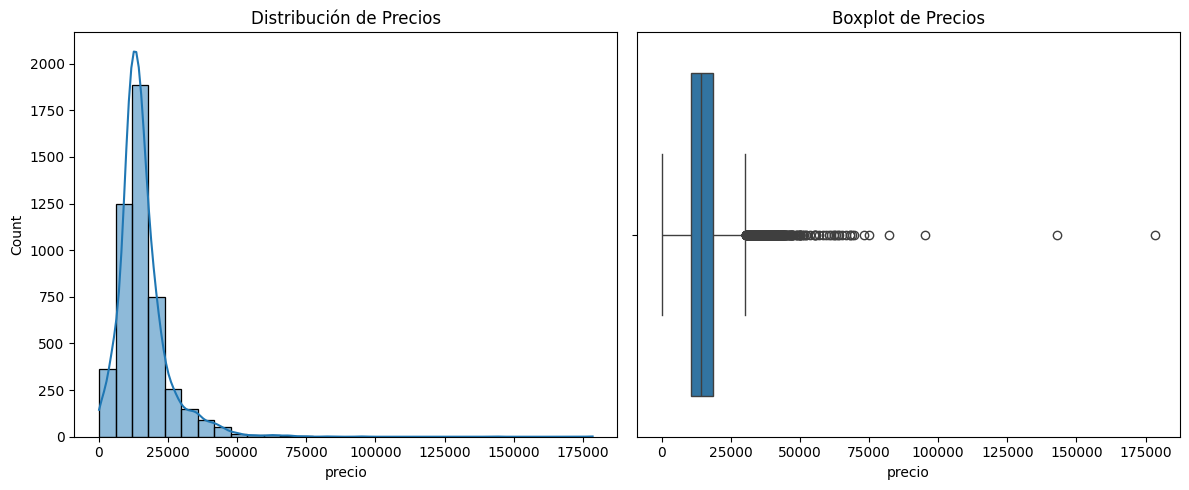

In [102]:
# Graficamos la distribución de la variable "precio" utilizando un histograma y un boxplot para identificar posibles valores atípicos.
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_cars["precio"], bins=30, kde=True)
plt.title("Distribución de Precios")
plt.subplot(1, 2, 2)
sns.boxplot(x=df_cars["precio"])
plt.title("Boxplot de Precios")
plt.tight_layout()
plt.show()  

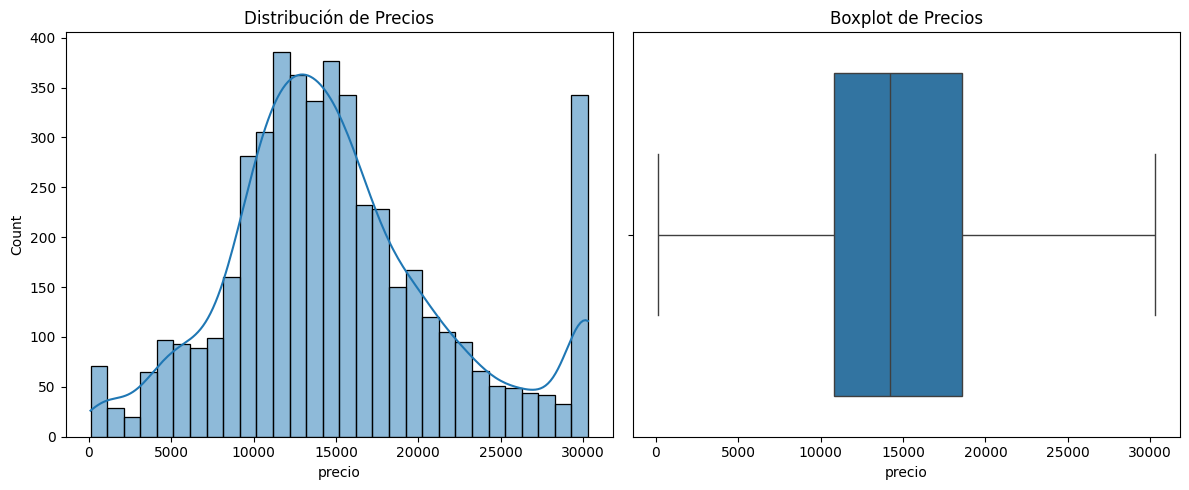

In [103]:
# Aplicamos limites a la variable "precio" para eliminar valores atípicos.
# Consideramos como límite inferios y superior el Q1 - 1.5*IQR y el Q3 + 1.5*IQR respectivamente.
# Los valores que se encuentren por debajo del límite inferior o por encima del límite superior serán considerados como valores atípicos y se los igualara a los limites correspondientes.
Q1 = df_cars["precio"].quantile(0.25)
Q3 = df_cars["precio"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_cars["precio"] = df_cars["precio"].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))

# Graficamos la distribución de la variable "precio" utilizando un histograma y un boxplot para identificar posibles valores atípicos.
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_cars["precio"], bins=30, kde=True)
plt.title("Distribución de Precios")
plt.subplot(1, 2, 2)
sns.boxplot(x=df_cars["precio"])
plt.title("Boxplot de Precios")
plt.tight_layout()
plt.show()  

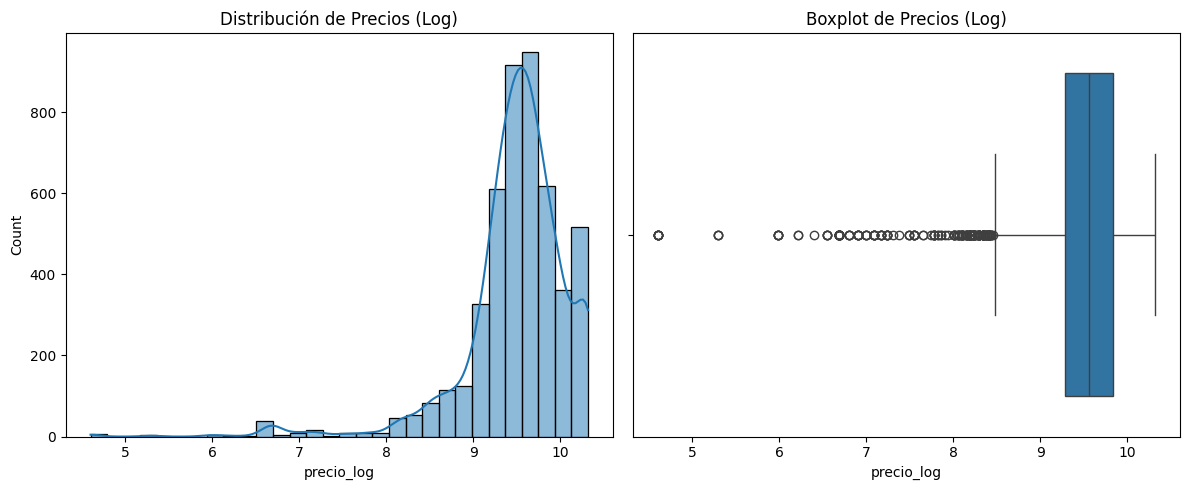

In [104]:
# Aplicamos Log al precio para reducir la influencia de los valores atípicos y graficamos nuevamente la distribución.
df_cars["precio_log"] = np.log(df_cars["precio"])
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_cars["precio_log"], bins=30, kde=True)
plt.title("Distribución de Precios (Log)")
plt.subplot(1, 2, 2)
sns.boxplot(x=df_cars["precio_log"])
plt.title("Boxplot de Precios (Log)")
plt.tight_layout()
plt.show()  

### Analizamos la columna "Marca"

In [105]:
# Analizamos los valores únicos de "marca"
tabla_marcas = (
    df_cars["marca"]
    .value_counts(dropna=False)
    .rename_axis("marca")
    .reset_index(name="cantidad")
)

pretty_table(tabla_marcas)

,marca,cantidad
0,BMW,"3,867"
1,nan,970


#### Analizis del Resultado

Intentaremos ver si el valor nan puede completarse a partir de los modelos, si continua habiendo una gran cantidad de nan, los reemplazmos con "No es BMW"

In [106]:
# Crear diccionario modelo -> marca más frecuente
map_modelo_marca = (
    df_cars[df_cars["marca"].notna()]
    .groupby("modelo")["marca"]
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
)

# Reemplazar nulos de marca usando modelo
df_cars["marca"] = df_cars["marca"].fillna(df_cars["modelo"].map(map_modelo_marca))

In [107]:
# Analizamos los valores únicos de "marca"
tabla_marcas = (
    df_cars["marca"]
    .value_counts(dropna=False)
    .rename_axis("marca")
    .reset_index(name="cantidad")
)

pretty_table(tabla_marcas)

,marca,cantidad
0,BMW,"4,831"
1,nan,6


#### Analizis del Resultado

Al ver que solo 6 casos quedan en nulos podemos proceder a eliminar la columna, dado que el porcentaje de variación es mínima.

In [87]:
# Eliminamos la columna marca
df_cars = df_cars.drop(columns=["marca"])
pretty_table(df_cars.head())

,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta,precio_log
0,118,"140,411.00",100.00,2012-02-01,diesel,black,nan,True,True,False,nan,True,nan,True,nan,"11,300.00",2018-01-01,9.33
1,M4,"13,929.00",317.00,nan,petrol,grey,convertible,True,True,False,nan,False,True,True,True,"30,300.00",2018-02-01,10.32
2,320,"183,297.00",120.00,2012-04-01,diesel,white,nan,False,False,False,nan,True,False,True,False,"10,200.00",2018-02-01,9.23
3,420,"128,035.00",135.00,nan,diesel,red,convertible,True,True,False,nan,True,True,True,nan,"25,100.00",2018-02-01,10.13
4,425,"97,097.00",160.00,nan,diesel,silver,nan,True,True,False,False,False,True,True,True,"30,300.00",2018-04-01,10.32


### Analizamos la columna "Asientos_traseros_plegables"

In [88]:
# Analizamos los valores únicos de "asientos_traseros_plegables"
tabla_asientos = (
    df_cars["asientos_traseros_plegables"]
    .value_counts(dropna=False)
    .rename_axis("asientos_traseros_plegables")
    .reset_index(name="cantidad")
)

pretty_table(tabla_asientos)


,asientos_traseros_plegables,cantidad
0,nan,"3,388"
1,False,"1,147"
2,True,302


/var/folders/l1/jhhz3wgj68j7g0x4mfq1dyfr0000gn/T/ipykernel_29882/2118318458.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


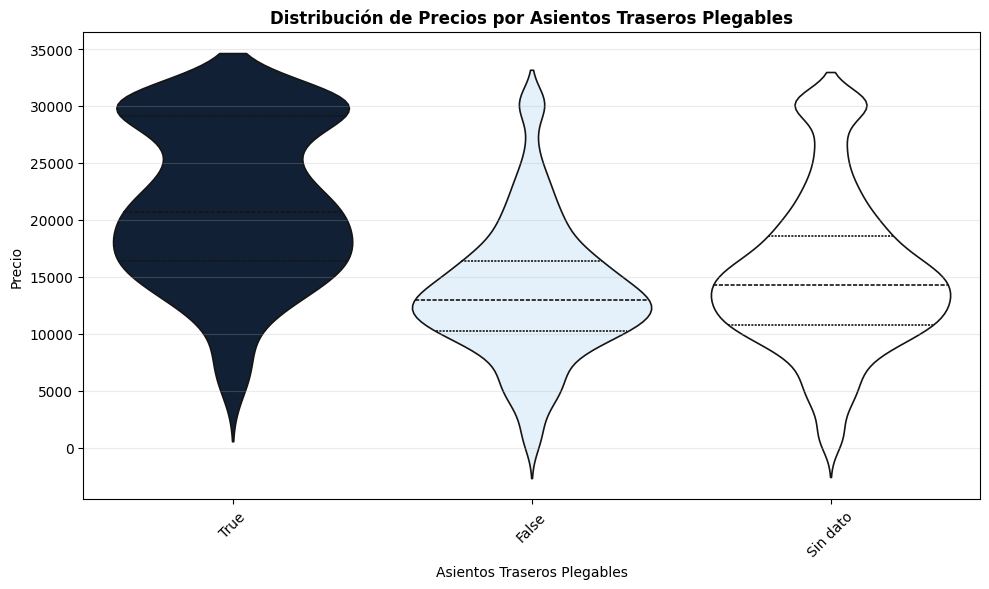

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos una copia para no modificar el dataset original
df_plot = df_cars.copy()

# Convertimos los nulos en una tercera categoría
df_plot["asientos_traseros_plegables_plot"] = (
    df_plot["asientos_traseros_plegables"]
    .fillna("Sin dato")
    .astype(str)
)

# Paleta similar a la pretty_table
palette = {
    "True": "#0b1f3a",      # azul marino
    "False": "#e0f2fe",     # celeste
    "Sin dato": "#ffffff"   # blanco
}

# Graficamos
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_plot,
    x="asientos_traseros_plegables_plot",
    y="precio",
    inner="quartile",
    palette=palette,
    order=["True", "False", "Sin dato"],
    linewidth=1.2
)

plt.title("Distribución de Precios por Asientos Traseros Plegables", fontweight="bold")
plt.xlabel("Asientos Traseros Plegables")
plt.ylabel("Precio")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

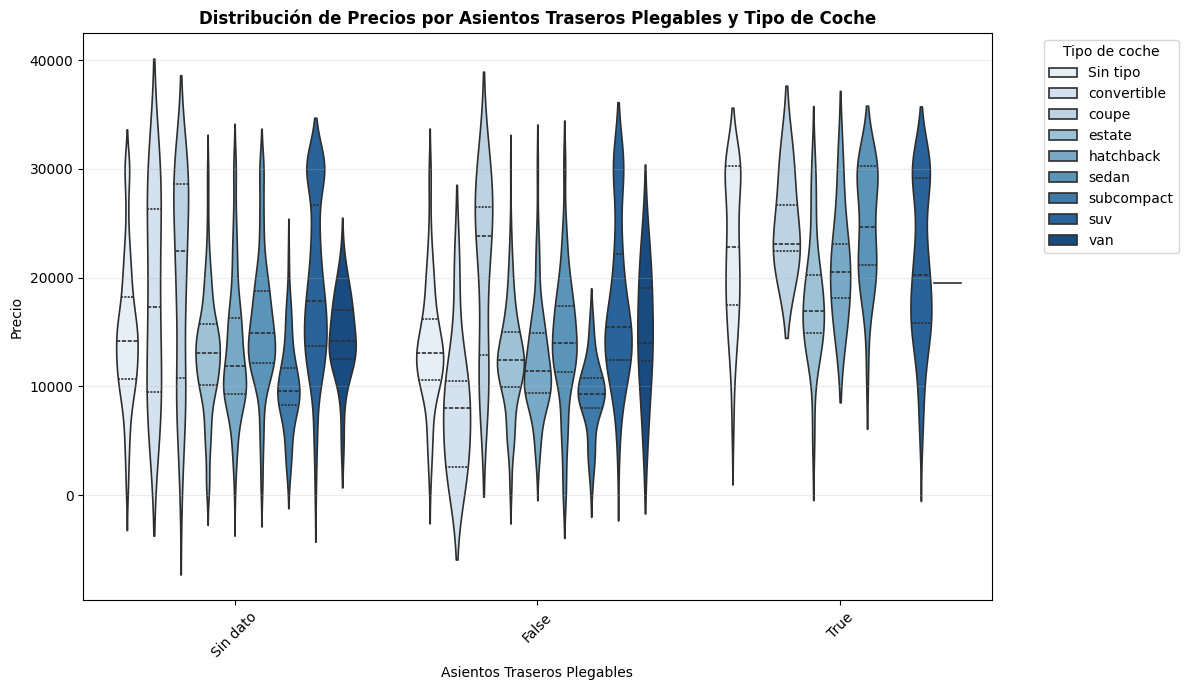

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_cars.copy()

# Convertimos nulos en categoría separada
df_plot["asientos_traseros_plegables_plot"] = (
    df_plot["asientos_traseros_plegables"]
    .fillna("Sin dato")
    .astype(str)
)

df_plot["tipo_coche_plot"] = (
    df_plot["tipo_coche"]
    .fillna("Sin tipo")
    .astype(str)
)

plt.figure(figsize=(12, 7))

sns.violinplot(
    data=df_plot,
    x="asientos_traseros_plegables_plot",
    y="precio",
    hue="tipo_coche_plot",
    inner="quartile",
    linewidth=1.2,
    palette="Blues"
)

plt.title(
    "Distribución de Precios por Asientos Traseros Plegables y Tipo de Coche",
    fontweight="bold"
)
plt.xlabel("Asientos Traseros Plegables")
plt.ylabel("Precio")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.legend(title="Tipo de coche", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [91]:
import pandas as pd
import numpy as np

df_test = df_cars.copy()

df_test["asientos_traseros_plegables_cat"] = (
    df_test["asientos_traseros_plegables"]
    .fillna("Sin dato")
    .astype(str)
)

df_test = df_test.dropna(subset=["precio"])

In [92]:
resumen = (
    df_test
    .groupby("asientos_traseros_plegables_cat")["precio_log"]
    .agg(
        cantidad="count",
        media="mean",
        mediana="median",
        std="std",
        minimo="min",
        maximo="max"
    )
    .reset_index()
)

pretty_table(resumen)

,asientos_traseros_plegables_cat,cantidad,media,mediana,std,minimo,maximo
0,False,"1,147",9.39,9.47,0.60,5.30,10.32
1,Sin dato,"3,388",9.49,9.57,0.63,4.61,10.32
2,True,302,9.91,9.94,0.37,8.50,10.32


In [93]:
from scipy.stats import kruskal

grupos = [
    grupo["precio"].values
    for _, grupo in df_test.groupby("asientos_traseros_plegables_cat")
]

stat, p_value = kruskal(*grupos)

print("Kruskal-Wallis statistic:", stat)
print("p-value:", p_value)

Kruskal-Wallis statistic: 283.9385367264067
p-value: 2.2056172516090694e-62


In [94]:
if p_value < 0.05:
    print("Hay diferencias estadísticamente significativas entre grupos.")
else:
    print("No hay evidencia suficiente de diferencias entre grupos.")

Hay diferencias estadísticamente significativas entre grupos.


## Eliminar Columnas Innecesarias